In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = "../data/raw/telco_customer_churn.csv"

In [3]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)

Dataset shape: (7043, 33)


In [4]:
TARGET = "Churn Label"
y = df[TARGET].copy()
X = df.drop(columns=[TARGET]).copy()

In [5]:
columns_to_drop = ["Count","Country","State","CustomerID","Churn Value","Churn Score","Churn Reason"]

In [6]:
X = X.drop(columns=columns_to_drop)
X["Total Charges"] = pd.to_numeric(X["Total Charges"],errors="coerce")

In [7]:
X.loc[(X["Tenure Months"] == 0) & (X["Total Charges"].isna()),"Total Charges"] = 0
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 25)
y shape: (7043,)


In [8]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

In [9]:
print("Numerical features:")
print(numerical_features)

Numerical features:
['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


In [10]:
X[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Total Charges,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550000,3786.600000,8684.800000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [11]:
y_numeric = y.map({"No": 0,"Yes": 1})

In [12]:
analysis_df = X.copy()
analysis_df["Churn"] = y_numeric
analysis_df.groupby("Churn")[numerical_features].mean().T

Churn,0,1
Zip Code,93518.212215,93532.352595
Latitude,36.287436,36.268614
Longitude,-119.804838,-119.782388
Tenure Months,37.569965,17.979133
Monthly Charges,61.265124,74.441332
Total Charges,2549.911442,1531.796094
CLTV,4490.921337,4149.414660


In [13]:
categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

In [14]:
print("Categorical features:")
print(categorical_features)

Categorical features:
['City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [15]:
cardinality = (X[categorical_features].nunique().sort_values(ascending=False))
print(cardinality)

Lat Long             1652
City                 1129
Payment Method          4
Internet Service        3
Multiple Lines          3
Online Security         3
Device Protection       3
Tech Support            3
Online Backup           3
Streaming TV            3
Contract                3
Streaming Movies        3
Phone Service           2
Dependents              2
Gender                  2
Senior Citizen          2
Partner                 2
Paperless Billing       2
dtype: int64


In [16]:
contract_churn = pd.crosstab(X["Contract"],y,normalize="index") * 100
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<Axes: xlabel='Contract'>

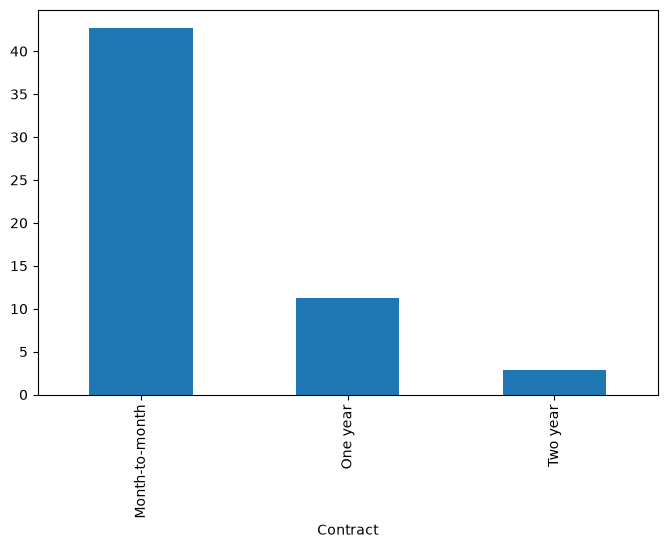

In [17]:
contract_churn["Yes"].plot(kind="bar",figsize=(8, 5))

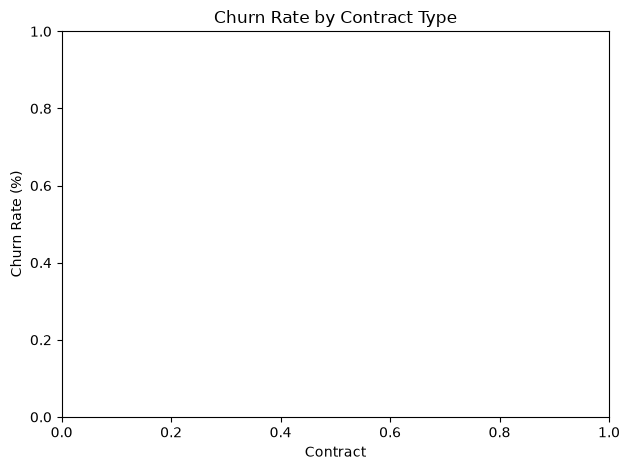

In [18]:
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
for feature in categorical_features:
    churn_rate = (pd.crosstab(X[feature],y,normalize="index")["Yes"] * 100).sort_values(ascending=False)

    print(f"\n{'=' * 60}")
    print(feature)
    print(f"{'=' * 60}")
    print(churn_rate)


City
City
Wrightwood      100.0
Tipton          100.0
Truckee         100.0
Twain           100.0
Johannesburg    100.0
                ...  
Arvin             0.0
Atascadero        0.0
Auberry           0.0
Upland            0.0
Volcano           0.0
Name: Yes, Length: 1129, dtype: float64

Lat Long
Lat Long
41.5837, -122.935922      100.0
34.437945, -119.77191     100.0
40.022184, -121.062384    100.0
34.358321, -117.618263    100.0
37.691561, -122.445202    100.0
                          ...  
37.023669, -121.946461      0.0
37.045728, -120.630682      0.0
32.733564, -117.033713      0.0
32.741852, -117.243453      0.0
41.251322, -122.105209      0.0
Name: Yes, Length: 1652, dtype: float64

Gender
Gender
Female    26.920872
Male      26.160338
Name: Yes, dtype: float64

Senior Citizen
Senior Citizen
Yes    41.681261
No     23.606168
Name: Yes, dtype: float64

Partner
Partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64

Dependents
Dependents
No     32.551699
Yes    

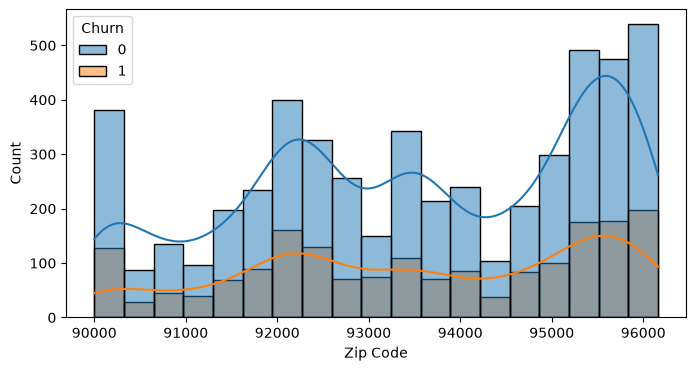

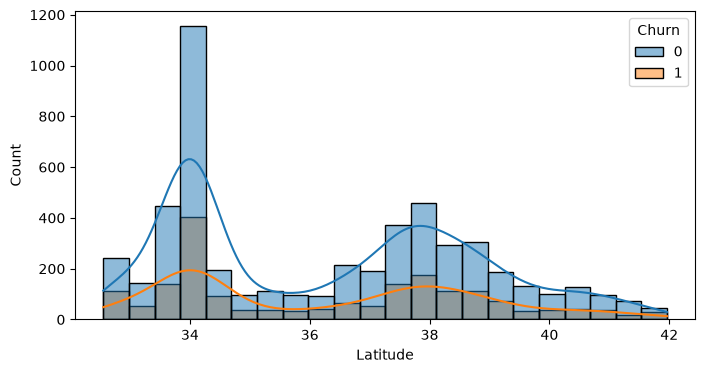

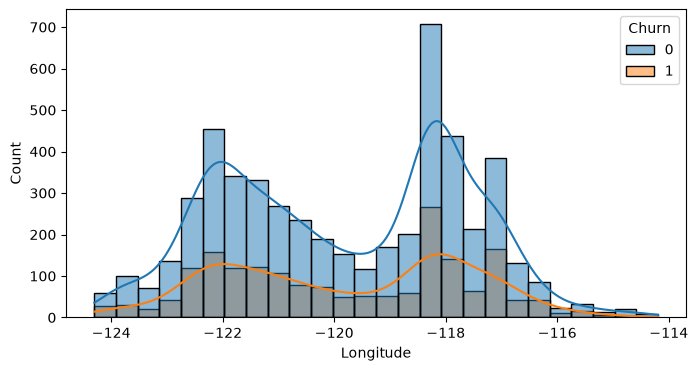

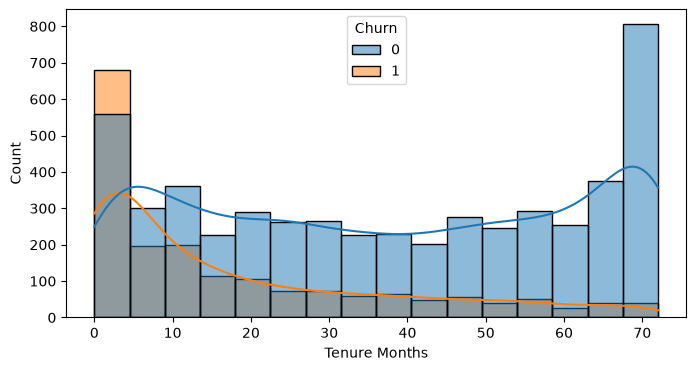

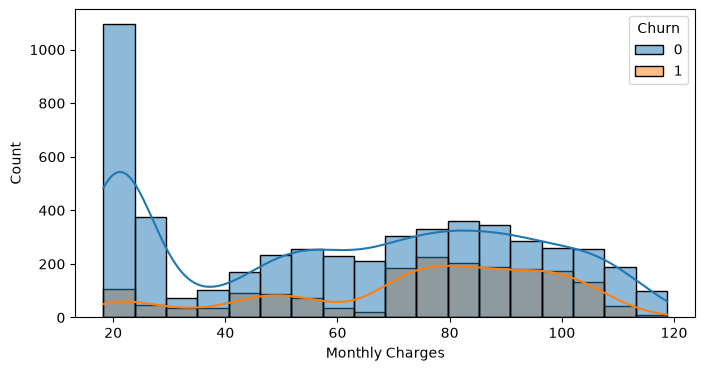

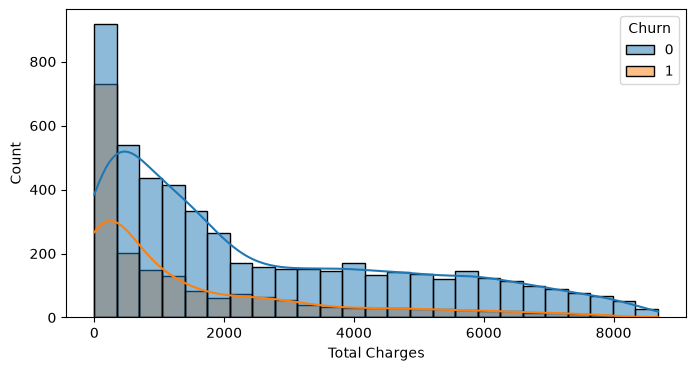

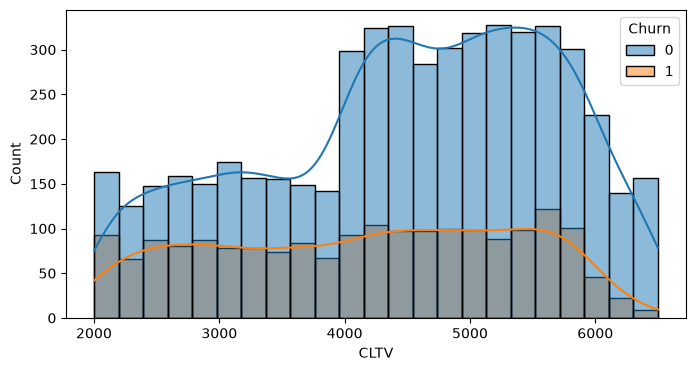

In [20]:
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=analysis_df,x=feature,hue="Churn",kde=True)

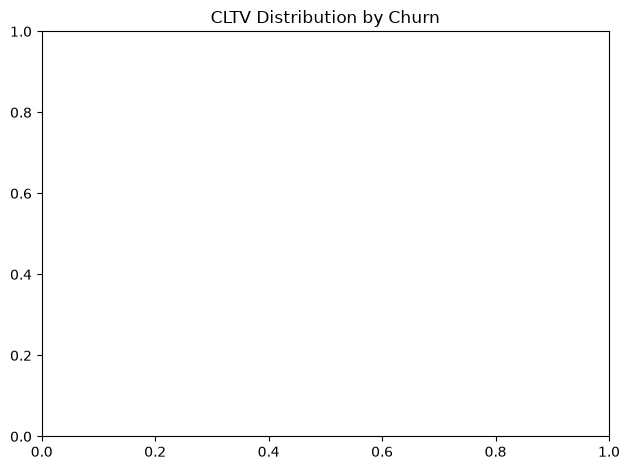

In [21]:
plt.title(f"{feature} Distribution by Churn")
plt.tight_layout()
plt.show()

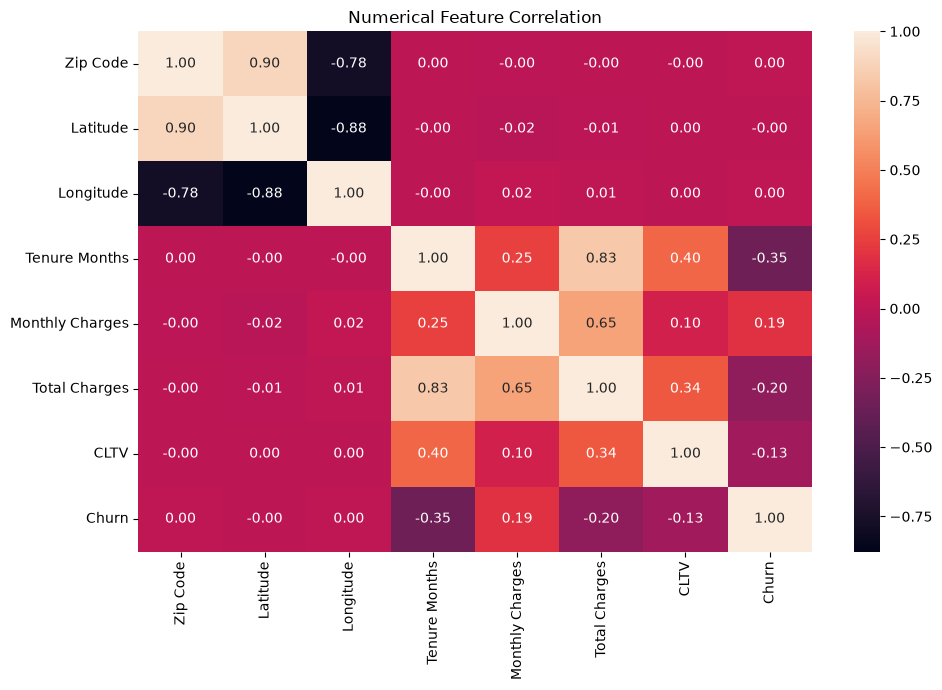

In [22]:
correlation = analysis_df[numerical_features + ["Churn"]].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation,annot=True,fmt=".2f")
plt.title("Numerical Feature Correlation")
plt.tight_layout()
plt.show()